In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import glob
import os

In [25]:
df_crimes = pd.read_csv("../data/processed/all_data_uncleaned.csv").copy()
len(df_crimes)


6391065

In [26]:
df_crimes.columns

Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context', 'Borough'],
      dtype='str')

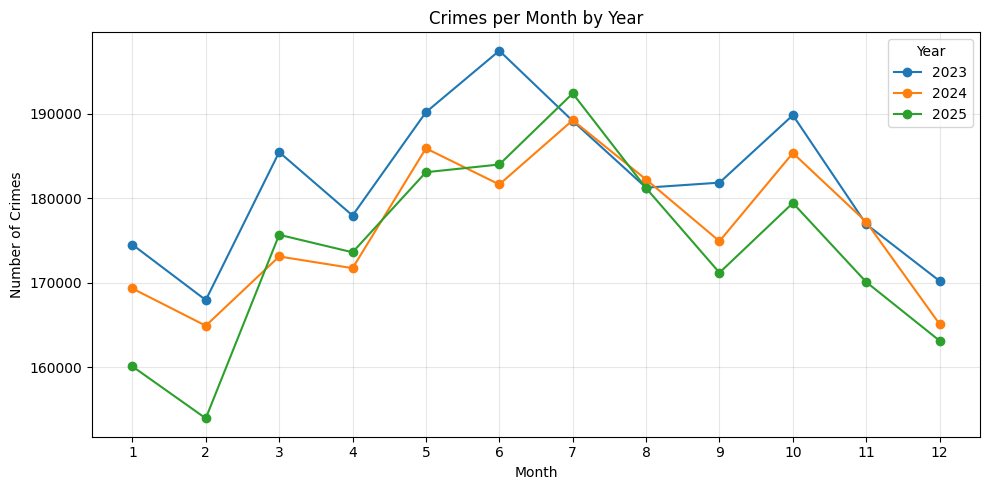

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df_crimes['Month'] = pd.to_datetime(df_crimes['Month'])

df_crimes['year'] = df_crimes['Month'].dt.year
df_crimes['Month'] = df_crimes['Month'].dt.month

monthly = (
    df_crimes
    .groupby(['year', 'Month'])
    .size()
    .unstack(level=0) 
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(10, 5))

for year in monthly.columns:
    plt.plot(monthly.index, monthly[year], marker='o', label=str(year))

plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.title('Crimes per Month by Year')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

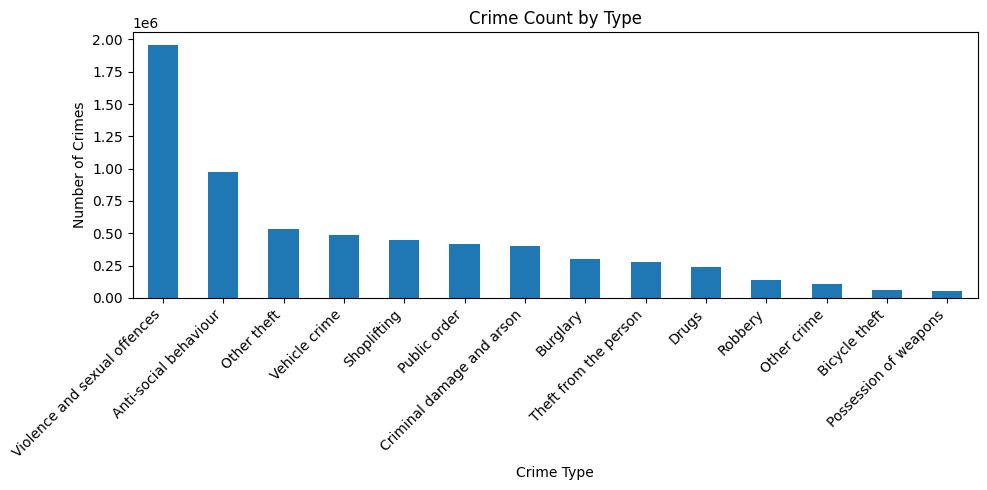

In [28]:
# Count crimes per type
crime_counts = df_crimes['Crime type'].value_counts()

plt.figure(figsize=(10, 5))
crime_counts.plot(kind='bar')

plt.xlabel('Crime Type')
plt.ylabel('Number of Crimes')
plt.title('Crime Count by Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Found 1 borough shapefiles


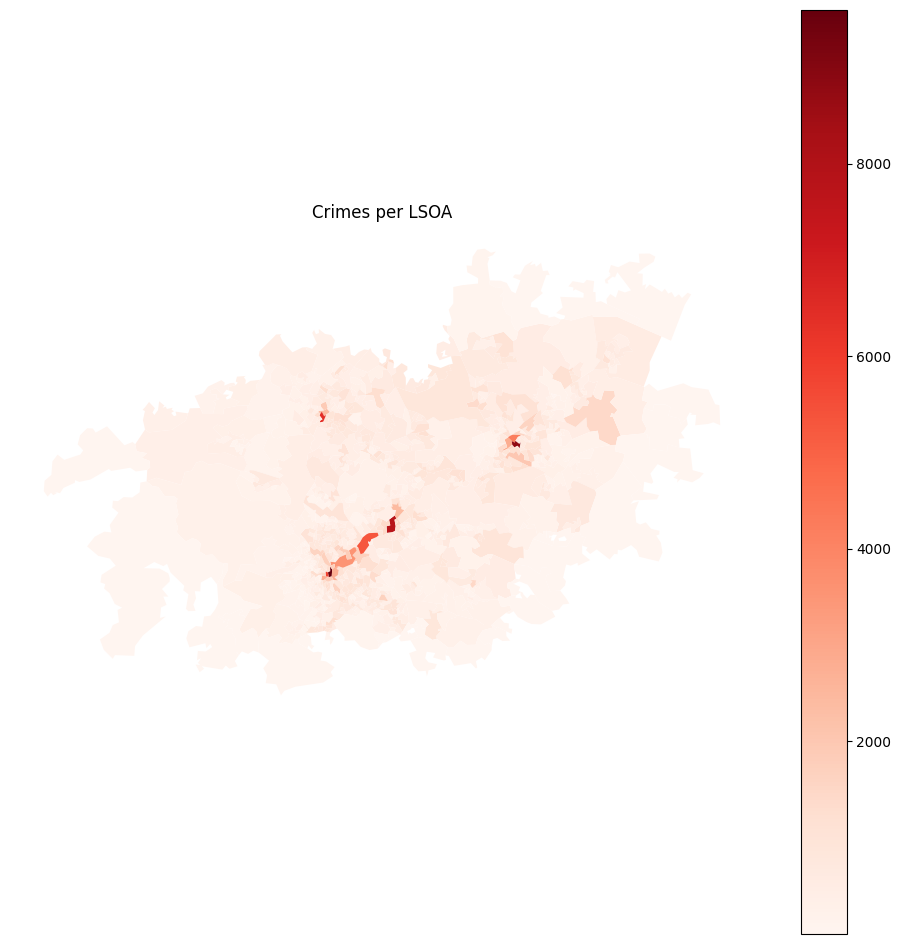

In [ ]:
police_forces = ["south-yorkshire", "motropolitan"]

for police_force in police_forces:
    police_force = gpd.read_file("../data/forc_kmls/"+police_force+".kml", driver="KML")

    lsoa_counts = (
        df_crimes
        .dropna(subset=['LSOA code'])
        .groupby('LSOA code')
        .size()
        .reset_index(name='crime_count')
    )

    base_path = "../data/LB_shp"
    shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)
    print(f"Found {len(shapefiles)} borough shapefiles")
    lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
    lsoa_uk = gpd.GeoDataFrame(
        pd.concat(lsoa_gdfs, ignore_index=True),
        crs=lsoa_gdfs[0].crs
    )

    lsoa_uk = lsoa_uk.to_crs(police_force.crs)

    lsoa_in_pf = gpd.sjoin(
        lsoa_uk,
        police_force,
        how="inner",
        predicate="intersects"
    )

    gdf = lsoa_in_pf.merge(
        lsoa_counts,
        left_on='LSOA21CD',
        right_on='LSOA code'
    )

    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    gdf.plot(
        column='crime_count',
        cmap='Reds',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey"}
    )

    ax.set_title("Crimes per LSOA")
    ax.axis('off')

    plt.show()

In [ ]:
cols = ['Crime type', 'Month', 'LSOA code']

missing = df_crimes[cols].isna().sum()
missing_pct = df_crimes[cols].isna().mean() * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
})

missing_df

,missing_count,missing_percent
Crime type,0,0.000000
Month,0,0.000000
LSOA code,58556,0.916217
